In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from dotenv import load_dotenv
from xgboost import XGBClassifier

import tensorflow as tf
tf.compat.v1.disable_eager_execution()
from alibi.explainers import CounterfactualProto

load_dotenv()
os.chdir('..')


MODELDIR = os.getenv("MODELDIR")
DATADIR  = os.getenv("DATADIR")


/Users/mattiadanisi/Desktop/XAI-People-Analytics/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model
model = XGBClassifier()
model.load_model(os.path.join(MODELDIR, "xgb_model.ubj"))

# Load data — saved as (X, y) tuples
X_train, y_train = joblib.load(os.path.join(DATADIR, "train_data.pkl"))
X_test,  y_test  = joblib.load(os.path.join(DATADIR, "test_data.pkl"))

def predict_fn(X: np.ndarray) -> np.ndarray:
    """
    Alibi expects a callable: np.ndarray -> np.ndarray of shape (n, n_classes).
    XGBoost's predict_proba already does this — we just need to ensure the
    input is a plain numpy array (not a DataFrame), which Alibi will pass.
    """
    return model.predict_proba(X)

def predict_fn(X: np.ndarray) -> np.ndarray:
    """
    Alibi expects a callable: np.ndarray -> np.ndarray of shape (n, n_classes).
    XGBoost's predict_proba already does this — we just need to ensure the
    input is a plain numpy array (not a DataFrame), which Alibi will pass.
    """
    return model.predict_proba(X)

CASE_STUDY_INDICES = {
    "Employee 214 (True Positive)":  214,
    "Employee 223 (False Positive)": 223,
    "Employee 240 (False Negative)": 240,
}

# Extract as numpy arrays — shape (1, n_features) each
instances = {
    name: X_test.iloc[[idx]].values
    for name, idx in CASE_STUDY_INDICES.items()
}

# Quick check
for name, arr in instances.items():
    prob_left = predict_fn(arr)[0][1]
    print(f"{name}: P(Left) = {prob_left:.1%}")

Employee 214 (True Positive): P(Left) = 97.3%
Employee 223 (False Positive): P(Left) = 94.3%
Employee 240 (False Negative): P(Left) = 1.2%


In [3]:
# Feature shape (excluding batch dimension)
feature_shape = (X_train.shape[1],)

# Scale for numerical features — CounterfactualProto uses L2 distance,
# so features need to be on comparable scales.
# Using the training data range (max - min) per feature as a simple scaler.
feature_range = (
    X_train.values.min(axis=0).astype(np.float32),
    X_train.values.max(axis=0).astype(np.float32),
)

cf = CounterfactualProto(
    predict=predict_fn,
    shape=(1, X_train.shape[1]),   # batch of 1
    kappa=0.1,    # minimum confidence gap between classes
    beta=0.1,    # weight of L1 sparsity term (fewer feature changes)
    gamma=100.0,  # weight of autoencoder reconstruction (we skip AE, so low effect)
    theta=10.0,   # weight of prototype proximity term
    use_kdtree=True,   # use k-d tree for prototype search (no autoencoder needed)
    max_iterations=500,
    feature_range=feature_range,
    c_init=1.0,
    c_steps=5,
)

# Fit: builds the k-d trees over training data
cf.fit(X_train.values.astype(np.float32))

No encoder specified. Using k-d trees to represent class prototypes.


CounterfactualProto(meta={
  'name': 'CounterfactualProto',
  'type': ['blackbox', 'tensorflow', 'keras'],
  'explanations': ['local'],
  'params': {
              'shape': (1, 44),
              'kappa': 0.1,
              'beta': 0.1,
              'feature_range': (array([1.800e+01, 1.030e+02, 1.000e+00, 1.000e+00, 1.000e+00, 3.000e+01,
       1.000e+00, 1.000e+00, 1.000e+00, 1.009e+03, 2.094e+03, 0.000e+00,
       1.100e+01, 3.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00], dtype=float32), array([6.0000e+01, 1.4990e+03, 2.9000e+01, 5.0000e+00, 4.0000e+00,
       1.0000e+02, 4.0000e+00, 5.0000e+00, 4.0000e+00, 1.9973e+04,
       2.6999e+04, 9.0000e+00, 2.5000e+0

## Counterfactual Explanations: What Would Need to Change?

For each case study predicted as **Left**, we ask: *what is the minimal set of feature changes that would flip the model's prediction to Stayed?*

`CounterfactualProto` finds the nearest point in feature space where the model outputs class 0 (Stayed), guided by a prototype from the training data.

In [4]:
def show_counterfactual(name, original_arr, cf_result, feature_names, threshold=0.01):
    """
    Print a table of features that changed from original to counterfactual.
    threshold: minimum absolute change to include (avoids float noise).
    """
    if cf_result.cf is None:
        print(f"[{name}] No counterfactual found.")
        return

    original = original_arr[0]
    counterfactual = cf_result.cf['X'][0]
    prob_orig = predict_fn(original_arr)[0][1]
    prob_cf   = predict_fn(cf_result.cf['X'])[0][1]

    diffs = []
    for i, feat in enumerate(feature_names):
        delta = counterfactual[i] - original[i]
        if abs(delta) > threshold:
            diffs.append({
                "Feature": feat,
                "Original": round(float(original[i]), 3),
                "Counterfactual": round(float(counterfactual[i]), 3),
                "Change": round(float(delta), 3),
            })

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  P(Left): {prob_orig:.1%}  →  {prob_cf:.1%}")
    print(f"{'='*60}")
    if diffs:
        df_diff = pd.DataFrame(diffs).sort_values("Change", key=abs, ascending=False)
        print(df_diff.to_string(index=False))
    else:
        print("  (no features changed above threshold)")

### Case 1 — Employee 214 (True Positive)
Model prediction: **96.7% Left** | Actual outcome: Left ✓

The model was correct. The counterfactual answers: *"What would this employee's profile need to look like for the model to predict they stay?"*

In [5]:
name_214 = "Employee 214 (True Positive)"
instance_214 = instances[name_214].astype(np.float32)
explanation_214 = cf.explain(instance_214, target_class=[0])
show_counterfactual(name_214, instance_214, explanation_214, X_test.columns.tolist())

2026-04-14 17:41:25.216267: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled



  Employee 214 (True Positive)
  P(Left): 97.3%  →  24.6%
                          Feature  Original  Counterfactual  Change
                    MonthlyIncome    2174.0        2183.900   9.900
                        DailyRate     756.0         746.100  -9.900
                       HourlyRate      99.0          91.500  -7.500
                              Age      21.0          23.100   2.100
          EnvironmentSatisfaction       1.0           1.500   0.500
                      MonthlyRate    9150.0        9149.699  -0.301
                  JobSatisfaction       2.0           2.300   0.300
                        Education       1.0           1.300   0.300
               YearsInCurrentRole       2.0           1.700  -0.300
             MaritalStatus_Single       1.0           0.900  -0.100
Department_Research & Development       0.0           0.100   0.100
     JobRole_Sales Representative       1.0           0.900  -0.100
    JobRole_Laboratory Technician       0.0           0.1

### Case 2 — Employee 223 (False Positive)
Model prediction: **86.1% Left** | Actual outcome: Stayed ✗

The model was wrong — this person stayed despite the high-risk prediction. The counterfactual answers: *"What minimal changes would make the model align with reality and predict Stayed?"*

In [6]:
name_223 = "Employee 223 (False Positive)"
instance_223 = instances[name_223].astype(np.float32)
explanation_223 = cf.explain(instance_223, target_class=[0])
show_counterfactual(name_223, instance_223, explanation_223, X_test.columns.tolist())


  Employee 223 (False Positive)
  P(Left): 94.3%  →  41.3%
                     Feature  Original  Counterfactual  Change
               MonthlyIncome    1200.0        1254.374  54.374
                   DailyRate     812.0         861.744  49.744
                 MonthlyRate    9724.0        9698.046 -25.954
                  HourlyRate      69.0          92.261  23.261
                         Age      18.0          29.732  11.732
           PercentSalaryHike      12.0          17.315   5.315
            DistanceFromHome      10.0           5.391  -4.609
       TrainingTimesLastYear       2.0           6.000   4.000
              JobInvolvement       2.0           4.000   2.000
             WorkLifeBalance       3.0           1.539  -1.461
           TotalWorkingYears       0.0           1.066   1.066
              YearsAtCompany       0.0           1.066   1.066
          YearsInCurrentRole       0.0           1.066   1.066
     YearsSinceLastPromotion       0.0           1.066   1

## Exporting counterfactual tables as PNG

The following cell reuses the explanations computed above and exports a formatted table for each case study to `notebooks/output/alibi/`. These PNGs are used as figures in the thesis.

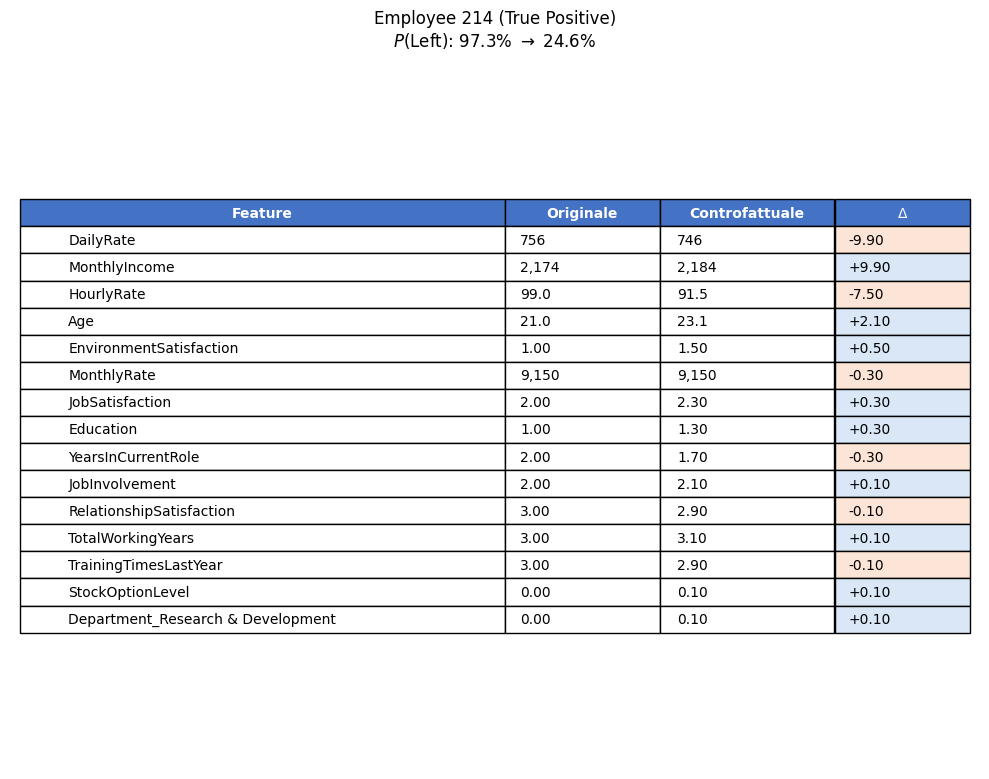

Saved: notebooks/output/alibi/cf_emp214_true_positive.png


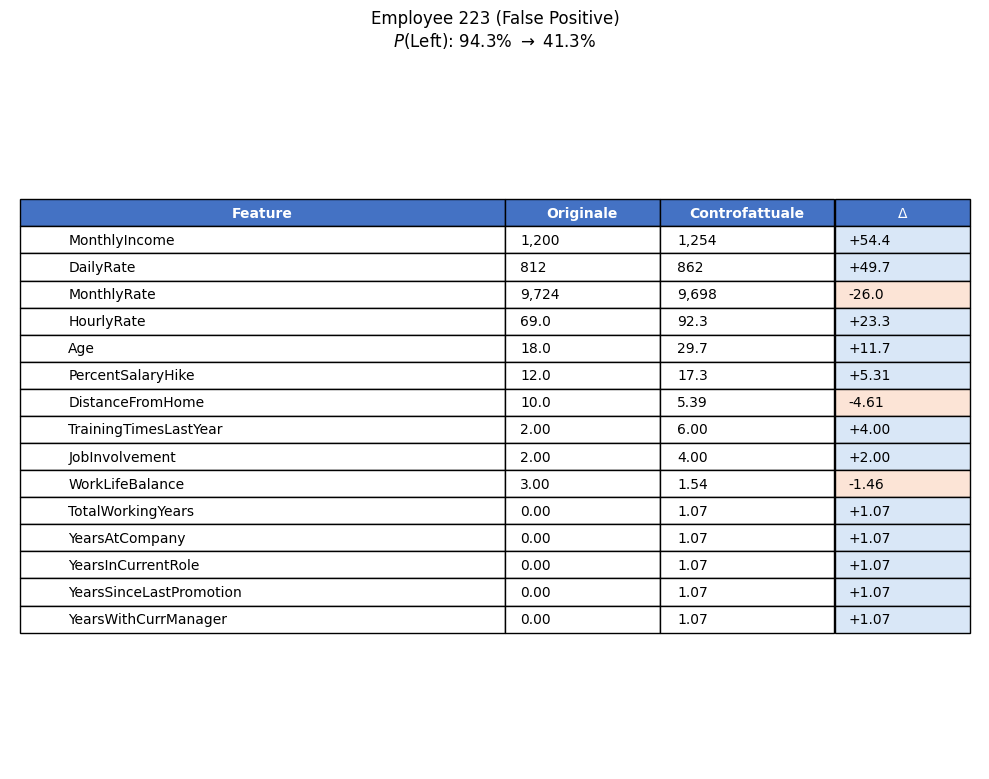

Saved: notebooks/output/alibi/cf_emp223_false_positive.png


In [7]:
def save_counterfactual_png(name, original_arr, cf_result, feature_names, out_path, top_n=15):
    """Render the counterfactual delta table as a matplotlib figure and save it."""
    if cf_result.cf is None:
        print(f"[{name}] No counterfactual found — skipping PNG.")
        return

    original = original_arr[0]
    counterfactual = cf_result.cf['X'][0]
    prob_orig = predict_fn(original_arr)[0][1]
    prob_cf = predict_fn(cf_result.cf['X'])[0][1]

    diffs = []
    for i, feat in enumerate(feature_names):
        delta = float(counterfactual[i] - original[i])
        if abs(delta) > 0.01:
            diffs.append((feat, float(original[i]), float(counterfactual[i]), delta))

    diffs.sort(key=lambda row: abs(row[3]), reverse=True)
    diffs = diffs[:top_n]

    def fmt(v):
        if abs(v) >= 100:
            return f"{v:,.0f}"
        if abs(v) >= 10:
            return f"{v:.1f}"
        return f"{v:.2f}"

    def fmt_delta(v):
        sign = "+" if v > 0 else ""
        return f"{sign}{fmt(v)}"

    cell_text = [
        [feat, fmt(orig), fmt(cf_val), fmt_delta(d)]
        for (feat, orig, cf_val, d) in diffs
    ]

    fig, ax = plt.subplots(figsize=(10, 0.42 * len(diffs) + 1.6))
    ax.axis("off")
    ax.set_title(
        f"{name}\n$P(\\mathrm{{Left}})$: {prob_orig:.1%} $\\rightarrow$ {prob_cf:.1%}",
        fontsize=12,
        pad=12,
    )

    tbl = ax.table(
        cellText=cell_text,
        colLabels=["Feature", "Originale", "Controfattuale", "$\\Delta$"],
        loc="center",
        cellLoc="left",
        colWidths=[0.50, 0.16, 0.18, 0.14],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.4)

    # Header styling
    for j in range(4):
        tbl[(0, j)].set_facecolor("#4472C4")
        tbl[(0, j)].set_text_props(color="white", weight="bold")

    # Delta cell colouring: positive = blue-ish, negative = orange-ish
    for i, (_, _, _, d) in enumerate(diffs, start=1):
        color = "#D9E7F7" if d > 0 else "#FCE4D6"
        tbl[(i, 3)].set_facecolor(color)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)
    print(f"Saved: {out_path}")


os.makedirs("notebooks/output/alibi", exist_ok=True)

save_counterfactual_png(
    name_214,
    instance_214,
    explanation_214,
    X_test.columns.tolist(),
    "notebooks/output/alibi/cf_emp214_true_positive.png",
)

save_counterfactual_png(
    name_223,
    instance_223,
    explanation_223,
    X_test.columns.tolist(),
    "notebooks/output/alibi/cf_emp223_false_positive.png",
)